# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。

今回は、ノードの埋め込みからnode2vecまでをまとめる。末尾のnode2vecを用いた分析は下記の書籍の内容とコードを参考にさせて頂いた。

- [データのつながりを活かす技術 | 技術評論社](https://gihyo.jp/book/2025/978-4-297-14784-6)

下記はグラフニューラルネットワークを理解するための参考サイト。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [CS224W | Home](https://web.stanford.edu/class/cs224w/index.html)
- [nn.labml.ai/ja/graphs](https://nn.labml.ai/#:~:text=%E2%9C%A8%20Graph%20Neural%20Networks)

## ノードの埋め込み

テーブル構造を対象にする機械学習モデルでは、一般的には各行ごとの特徴量をもとに、ターゲット変数の値を予測する。つまり、各処理は別個に扱われている状態といえる。一方でグラフデータでは、各ノードが影響し合うことが想定されるため、先程の方法では、ノードの関係をうまく学習し、予測できないケースも存在する。このような問題に対処するために、特徴量の要素を埋め込んだベクトルを生成することで、行間の関係性を考慮した新しい特徴量を作成する。

ノードの埋め込み(node embeding)は、単語の埋め込み(word embeding)をもとにしている。単語の埋め込みは、テキストの単語を低次元のベクトル(分散表現)に変換し、潜在的な意味を数値的に扱えるようにしている。その中でも有名なのがword2vecである。word2vecはコーパス(大量のテキストデータ)において、ある単語はその周辺の単語から予測できる、という分布仮説をもとに、単語ベクトルを学習する。詳細は検索すればたくさん出てくるので、省略するが、周辺単語から中心単語を推測する(CBOW:Continuous Bag-of-Words Model)、中心単語から周辺単語を推測することを行い(Skip-gram:Continuous Skip-Gram Model)、単語の意味を捉えた単語ベクトルを生成する。

word2vecの学習方法で重要な「Skip-gramモデル」「Negative Sampling」について簡単に触れておく。Skip-gramは「共起を学習する枠組み」、Negative Samplingは「スケールのための仕組み」である。

Skip-gramモデルは、「ある単語が与えられたとき、その周囲に現れる単語を予測する」モデル。文章中で実際に近くに現れた単語ペアを「正例」として学習し、中心語と文脈語のベクトルの内積が大きくなるように調整する。これにより、同じような文脈で使われる単語同士のベクトルが自然と近くなる。

Negative Samplingは、この学習を効率よく行うための手法。本来は語彙全体に対して確率を計算する必要があるが、計算量が大きくなるため、正例ペアに対していくつかの「ランダムに選んだ単語（負例）」を用意し、「正例は近づける」「負例は遠ざける」ということを行う。これにより、計算量を削減しながら、単語間の共起関係をうまく埋め込み空間に反映させることができる。



## node2vecとは

ノードの埋め込みを行う方法には DeepWalk、LINE、NetMF などさまざまな手法があるが、ここでは node2vec に焦点を当てる。詳細は下記の論文を見てもらうとして、ここでは簡単にまとめておく。

- [node2vec: Scalable Feature Learning for Networks](https://arxiv.org/abs/1607.00653)

node2vecでは、まずグラフの上をランダムウォークしてノードの並びを作る。これはイメージとしては「グラフの上をランダムに散歩して、そのときに通ったノードの順番を記録する」ようなものだ。例えば、次のようなグラフがあったとする。

```python
A — B — C
    |
    D — E
```

ここでノード A からランダムウォークをすると、例えば次のようなノードの並びが得られる。

```python
A → B → D → E → D → B → C
```

この並びは、文章における単語列のように扱うことができる。つまり「近くに現れやすいノード同士は関係が強い」と考える。node2vecの特徴は、ランダムウォークの動きを$p,q$という2つのパラメータで調整できる点にある。これらを変えることで、

- 近くのノードを広く見て回る動き（幅優先探索に近い）
- ある方向にどんどん進んでいく動き（深さ優先探索に近い）

これらのバランスをコントロールできる。例えば、近くのノードを優先して歩くようにすると「同じコミュニティに属するノード」が強く関連付けられ、遠くへ進みやすくすると「似た役割を持つノード」が似たベクトルになりやすい。この違いは、後の計算イメージや実装で確認する。

次に、こうして得られたノードの並びから 「中心ノード」と「周辺ノード」 のペアを作る。これは word2vec の Skip-gram と同じ考え方である。例えば次の並びがあったとする。

```python
A  B  D  E
```

ウインドウサイズを1とすると、

- B の周辺 → A, D
- D の周辺 → B, E

となるので、次のようなペアが作られる。

```python
(B, A)
(B, D)
(D, B)
(D, E)
```

学習では「中心ノードから周辺ノードを予測できるように」ノードのベクトルを調整していく。すると、ランダムウォークの中でよく一緒に現れるノード同士のベクトルが自然と近くなる。まとめると node2vec は、

- グラフ上をランダムに歩いてノードの並びを作る
- その並びから「中心ノードと周辺ノード」のペアを作る
- Skip-gramの方法でベクトルを学習する

という流れで、グラフ構造の中で似た位置関係にあるノードを似たベクトルに埋め込む方法である。

## node2vecの計算イメージ

さきほどの説明を汚いが、手で計算したものが下記の画像。

<div align="center"><img src="./node2vec1.png" width="800"></div>
<div align="center"><img src="./node2vec2.png" width="800"></div>


## node2vecの実装

ニューラルネットワークならびにグラフニューラルネットワーク、node2vecの大元にあるword2vecについても理解が怪しいので、下記は再現したものの注意。先程の計算イメージとは乱数設定などの違いで当然一致しない。

In [63]:
import torch
import torch.nn as nn
import random

torch.manual_seed(0)
random.seed(0)

In [64]:
# グラフ定義
# A(0) -- B(1) -- C(2)
# |        |
# D(3) -- E(4)
edge_index = torch.tensor([
    [0, 0, 1, 1, 3],
    [1, 3, 2, 4, 4]
], dtype=torch.long)

num_nodes = 5

# adjacency list 作成
adj = [[] for _ in range(num_nodes)]
for src, dst in edge_index.t().tolist():
    adj[src].append(dst)
    adj[dst].append(src)

print("Adjacency List:")
for i in range(num_nodes):
    print(f"{i} -> {adj[i]}")

Adjacency List:
0 -> [1, 3]
1 -> [0, 2, 4]
2 -> [1]
3 -> [0, 4]
4 -> [1, 3]


In [65]:
# node2vec ランダムウォーク
def node2vec_walk(start_node, walk_length, p, q):
    walk = [start_node]
    while len(walk) < walk_length:
        curr = walk[-1]
        neighbors = adj[curr]
        if len(neighbors) == 0: break

        if len(walk) == 1:
            next_node = random.choice(neighbors)
        else:
            prev = walk[-2]
            probs = []
            for dst in neighbors:
                if dst == prev:
                    probs.append(1 / p)        # 元に戻る (d=0)
                elif dst in adj[prev]:
                    probs.append(1.0)          # 1つ前とも繋がっている (d=1)
                else:
                    probs.append(1 / q)        # 遠ざかる (d=2)

            probs = torch.tensor(probs, dtype=torch.float)
            next_node = neighbors[torch.multinomial(probs, 1).item()]
        
        walk.append(next_node)
    return walk

walk_length = 4 # ウォークの長さ
walks_per_node = 2  # ノードごとのウォークリストの数 ノード数が5でwalks_per_nodeが2なら5*2=10のウォークリストが生成される
p = 1.0
q = 1.0

walks = []

for node in range(num_nodes):
    for _ in range(walks_per_node):
        walk = node2vec_walk(node, walk_length, p, q)
        walks.append(walk)

print("Generated Walks:")
for w in walks:
    print(w)

Generated Walks:
[0, 3, 4, 1]
[0, 3, 0, 1]
[1, 0, 3, 4]
[1, 2, 1, 4]
[2, 1, 2, 1]
[2, 1, 4, 3]
[3, 4, 1, 4]
[3, 4, 3, 4]
[4, 3, 0, 3]
[4, 1, 4, 1]


In [66]:
# ===============================
# 中心→周辺ペア生成（Skip-gram 用の正例データ作成）
# ===============================
#
# 目的：
#   ランダムウォークで得られた各 walk を「文章」とみなし、
#   その中で「中心ノード(center) → 周辺ノード(context)」のペアを作る。
#   これが Skip-gram の学習データになる。
#
# 数式対応：
#   各中心ノード u に対して、
#   近傍 window 内のノード v を取り出し、
#       (u, v)
#   を正例ペアとして収集する。
#
# context_size = C のとき、
#   各 center について
#       v ∈ { walk[i-C], ..., walk[i-1], walk[i+1], ..., walk[i+C] }
#   が対象となる（範囲外は除く）。
#
# 例：
#   walk = [1, 0, 3, 4] -> 1リストから6個のペアが生成されるなので60
#   context_size = 1 の場合
#   center=0 (i=1) のとき
#       前後1つ → [1, 3]
#       → (0,1), (0,3) が生成される
#   center=3 (i=1) のとき
#       前後1つ → [0, 4]
#       → (3,0), (3,4) が生成される
#
# 全 walk についてこれを行い、
# すべての (center, context) を pairs に集める。
# ===============================

context_size = 1
pairs = []

for walk in walks:                # 各ランダムウォーク（文章）ごとに処理
    for i in range(len(walk)):    # walk内の各ノードを中心(center)として順番に見る
        center = walk[i]

        # centerの前後 context_size 分だけ範囲を決める
        for j in range(
            max(0, i - context_size),              # 左端を超えないようにする
            min(len(walk), i + context_size + 1), # 右端を超えないようにする
        ):
            if i != j:  # 自分自身は除く
                # (中心ノード, 周辺ノード) の正例ペアを追加
                pairs.append((center, walk[j]))

pairs = torch.tensor(pairs)

print("Positive pairs shape:", pairs.shape)
print("pairs:", pairs)

Positive pairs shape: torch.Size([60, 2])
pairs: tensor([[0, 3],
        [3, 0],
        [3, 4],
        [4, 3],
        [4, 1],
        [1, 4],
        [0, 3],
        [3, 0],
        [3, 0],
        [0, 3],
        [0, 1],
        [1, 0],
        [1, 0],
        [0, 1],
        [0, 3],
        [3, 0],
        [3, 4],
        [4, 3],
        [1, 2],
        [2, 1],
        [2, 1],
        [1, 2],
        [1, 4],
        [4, 1],
        [2, 1],
        [1, 2],
        [1, 2],
        [2, 1],
        [2, 1],
        [1, 2],
        [2, 1],
        [1, 2],
        [1, 4],
        [4, 1],
        [4, 3],
        [3, 4],
        [3, 4],
        [4, 3],
        [4, 1],
        [1, 4],
        [1, 4],
        [4, 1],
        [3, 4],
        [4, 3],
        [4, 3],
        [3, 4],
        [3, 4],
        [4, 3],
        [4, 3],
        [3, 4],
        [3, 0],
        [0, 3],
        [0, 3],
        [3, 0],
        [4, 1],
        [1, 4],
        [1, 4],
        [4, 1],
        [4, 1],
       

In [67]:
# Embedding 初期化
embedding_dim = 2
embedding = nn.Embedding(num_nodes, embedding_dim)

print("Initial embedding:")
print(embedding.weight)

Initial embedding:
Parameter containing:
tensor([[-0.6776,  1.0422],
        [-1.9513,  0.4186],
        [ 3.3214,  0.8764],
        [ 1.2345, -1.1642],
        [-0.0240,  0.6480]], requires_grad=True)


In [68]:
# Skip-gram + Negative Sampling 損失
def compute_loss(pos_pairs, num_negative_samples=3):
    num_pos = pos_pairs.size(0)

    # ----- Positive -----
    pos_u = embedding(pos_pairs[:, 0])
    pos_v = embedding(pos_pairs[:, 1])

    pos_score = (pos_u * pos_v).sum(dim=1)
    pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-15).mean()

    # ----- Negative -----
    neg_centers = torch.randint(num_nodes, (num_pos * num_negative_samples, ))
    neg_context = torch.randint(num_nodes, (num_pos * num_negative_samples, ))
    neg_pairs = torch.stack([neg_centers, neg_context], dim=1)

    neg_u = embedding(neg_pairs[:, 0])
    neg_v = embedding(neg_pairs[:, 1])

    neg_score = (neg_u * neg_v).sum(dim=1)
    neg_loss = -torch.log(1 - torch.sigmoid(neg_score) + 1e-15).mean()

    return pos_loss + neg_loss

loss = compute_loss(pairs)
print("Initial Loss:", loss.item())

Initial Loss: 3.569218397140503


In [69]:
optimizer = torch.optim.Adam(embedding.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    loss = compute_loss(pairs)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f}")

print("\nFinal Embeddings:")
print(embedding.weight.detach())

Epoch 020 | Loss: 3.0190
Epoch 040 | Loss: 2.7602
Epoch 060 | Loss: 2.1904
Epoch 080 | Loss: 1.9058
Epoch 100 | Loss: 1.8844

Final Embeddings:
tensor([[-0.1896,  0.1817],
        [-1.1021,  1.4131],
        [ 2.4624,  1.7224],
        [ 0.4050, -0.7504],
        [-0.5699, -0.0720]])


## node2vecを利用したデータ分析

ここからは冒頭で記載した書籍を参考にnode2vecを利用した分析を行う。コードは下記を参考にさせて頂いた。流れとしては、node2vecの特徴量ありなしで分類精度を比較して、node2vecの有効性を検証するという流れ。

- [第5章 ノード埋め込み](https://github.com/ghmagazine/networkdata_practice_book/blob/main/chapter05/05_node_embedding.ipynb)

In [70]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import Planetoid

使用するサンプルデータは、論文の引用ネットワークのデータセット`Cora`を使用する。`Cora`データセットは1つのグラフ、2708のノード、1433の特徴量、7つのクラスから構成される。

In [71]:
# torch_geometric の Dataset としてダウンロード
dataset = Planetoid(root="./dataset", name="Cora", split="full")
print()
print(f"Dataset: {dataset}:")
print("======================")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of nodes: {dataset._data.num_nodes}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"class: {dataset.y.unique()}")
print(f"Type of dataset: {type(dataset)}")
print(f"Type of network: {type(dataset._data)}")
print()
print(dataset[0])
print(
    "==========================================================================================================="
)


Dataset: Cora():
Number of graphs: 1
Number of nodes: 2708
Number of features: 1433
Number of classes: 7
class: tensor([0, 1, 2, 3, 4, 5, 6])
Type of dataset: <class 'torch_geometric.datasets.planetoid.Planetoid'>
Type of network: <class 'torch_geometric.data.data.Data'>

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [72]:
from collections import Counter
from torch_geometric.utils.convert import to_networkx

# PyTorch Geometric -> NetworkX への変換
cora_network = to_networkx(dataset._data, node_attrs=["y"])
# 重いのでグラフ化したければ下記を実行
# nx.draw(cora_network, node_size=10)

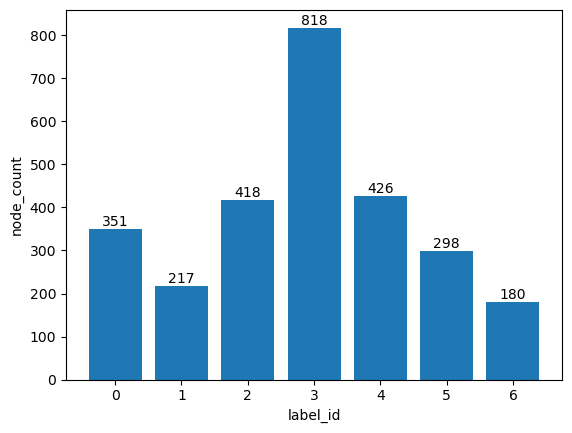

In [73]:
# 各論文の技術領域に対応するIDを取得
labels = nx.get_node_attributes(cora_network, "y")
label_counter = Counter(labels.values())

# ラベル分布を表示（カウント数も棒グラフ上に表示）
keys_sorted = [k for k, _ in sorted(label_counter.items())]
vals_sorted = [v for _, v in sorted(label_counter.items())]

plt.bar(keys_sorted, vals_sorted)
plt.xlabel("label_id")
plt.ylabel("node_count")

# カウント数を棒グラフの上に表示
for x, y in zip(keys_sorted, vals_sorted):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=10)

ここでは`Cora`データセットがすでに持っている訓練用マスク、検証用マスク、テスト用マスクは使用せず、ランダムにデータを分ける。全体の40%をテスト用に分割する。

In [74]:
from torch_geometric.transforms import RandomNodeSplit

# ノードを学習データとテストデータに分割
node_splitter = RandomNodeSplit(
    split="train_rest",
    num_splits=1,
    num_val=0.0,
    num_test=0.4,
    key="y",
)
splitted_data = node_splitter(dataset._data)
print(splitted_data.node_attrs())
print(splitted_data.train_mask)
print(splitted_data.test_mask)

['x', 'val_mask', 'train_mask', 'y', 'test_mask']
tensor([ True,  True,  True,  ..., False,  True,  True])
tensor([False, False, False,  ...,  True, False, False])


In [75]:
splitted_data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

`node2vec`を計算する。引数の説明は下記の通り。

- `embedding_dim`: ベクトルの次元数
- `walk_length`: ランダムウォークの長さ
- `context_size`: ウインドウのサイズ
- `walks_per_node`: ノードごとのランダムウォーク実行回数
- `p,q`: 幅優先、深さ優先を制御するパラメタ

データそのものは渡さずとも、エッジ情報を渡すことで内部で処理してくれる。また、node2vecは教師なし学習なので、全データで学習することはリークにはならない。


In [76]:
import torch
from torch_geometric.nn import Node2Vec

# node2vecモデルの定義
device = "cuda" if torch.cuda.is_available() else "cpu"
n2v_model = Node2Vec(
    splitted_data.edge_index,
    embedding_dim=64,
    walk_length=5,
    context_size=5,
    walks_per_node=10,
    num_negative_samples=1,
    p=1,
    q=1,
    sparse=False,
).to(device)

# 最適化アルゴリズムの選択
n2v_optimizer = torch.optim.Adam(
    list(n2v_model.parameters()),
    lr=0.01,
)

損失の計算は、正例である`pos_rw`、負例である`nega_rw`を通じて計算される。

In [77]:
from tqdm import tqdm


# node2vec の学習を行う関数の定義
def train_n2v() -> float:
    n2v_model.train()
    total_loss = 0.0

    loader = n2v_model.loader(batch_size=8, shuffle=True)

    # サンプリングしたランダムウォークの読み込み
    for pos_rw, neg_rw in tqdm(loader):
        n2v_optimizer.zero_grad()

        # 損失の計算
        loss = n2v_model.loss(
            pos_rw.to(device),
            neg_rw.to(device),
        )
        loss.backward()
        n2v_optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [78]:
for epoch in range(30):
    loss = train_n2v()
    print(f"train loss : {loss:.4f}")

100%|██████████| 339/339 [00:00<00:00, 958.42it/s] 


train loss : 5.4759


100%|██████████| 339/339 [00:00<00:00, 1026.20it/s]


train loss : 3.6904


100%|██████████| 339/339 [00:00<00:00, 1000.46it/s]


...

train loss : 0.8745


100%|██████████| 339/339 [00:00<00:00, 922.59it/s]


train loss : 0.8776


100%|██████████| 339/339 [00:00<00:00, 800.42it/s]

train loss : 0.8754


ノードに対応する順番に並び替えて埋め込み行列を作成する。

In [79]:
# ノードに対応するベクトルを行列形式で獲得
embedding_matrix = n2v_model.embedding(
    torch.arange(splitted_data.num_nodes)  # splitted_data.num_nodes: 2708
)
print(embedding_matrix.shape)

torch.Size([2708, 64])


あらかじめ用意されている特徴量のサイズも確認しておく。node2vecは64次元で、Bag-of-Wordsの特徴量は1433次元である。

In [80]:
# あらかじめ与えられた特徴量へのアクセス
print(splitted_data.x.shape)

torch.Size([2708, 1433])


まずはロジスティクス回帰分析×Bag-of-Wordsのベースラインモデルを用いて、テストデータに対する推論を行い、モデルを評価する。

In [81]:
# あらかじめ与えられた特徴量を用いたロジスティック回帰モデルの学習
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_classifier = LogisticRegression(
    max_iter=1000,
    random_state=0,
)
X_train = splitted_data.x[splitted_data.train_mask].numpy()
y_train = splitted_data.y[splitted_data.train_mask].numpy()
baseline_classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


ロジスティクス回帰分析×Bag-of-Wordsのベースラインモデルでは、テストデータの評価は、accuracyでは74%であった。

In [82]:
# 評価データに対する推論
X_test = splitted_data.x[splitted_data.test_mask].numpy()
y_true = splitted_data.y[splitted_data.test_mask].numpy()
y_pred = baseline_classifier.predict(X_test)

# 評価結果の表示
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.65      0.64       152
           1       0.82      0.65      0.72        83
           2       0.87      0.87      0.87       170
           3       0.71      0.85      0.78       316
           4       0.82      0.66      0.73       167
           5       0.69      0.68      0.68       117
           6       0.74      0.59      0.66        78

    accuracy                           0.74      1083
   macro avg       0.75      0.71      0.73      1083
weighted avg       0.75      0.74      0.74      1083



次はロジスティクス回帰分析×node2vecのモデルを用いて、テストデータに対する推論を行い、モデルを評価する。

In [83]:
# ノードの分散表現を特徴量に加えたロジスティック回帰モデルの学習
n2v_classifier = LogisticRegression(
    max_iter=1000,
    random_state=0,
)
X_train = torch.cat(
    (
        splitted_data.x[splitted_data.train_mask],
        embedding_matrix[splitted_data.train_mask],
    ),
    dim=1,
).detach().numpy()
y_train = splitted_data.y[splitted_data.train_mask].numpy()
n2v_classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


テストデータの評価は、accuracyでは79%で5ptほど上昇している。

In [84]:
# テストデータに対する推論
X_test = torch.cat(
    (
        splitted_data.x[splitted_data.test_mask],
        embedding_matrix[splitted_data.test_mask],
    ),
    dim=1,
).detach().numpy()
y_true = splitted_data.y[splitted_data.test_mask].numpy()
y_pred = n2v_classifier.predict(X_test)

# 評価結果の表示
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       152
           1       0.87      0.82      0.84        83
           2       0.90      0.91      0.90       170
           3       0.78      0.86      0.82       316
           4       0.81      0.72      0.77       167
           5       0.76      0.75      0.76       117
           6       0.76      0.64      0.69        78

    accuracy                           0.79      1083
   macro avg       0.79      0.77      0.78      1083
weighted avg       0.79      0.79      0.79      1083



最後はグラフニューラルネットワーク×node2vec特徴量のモデルで精度を確かめる。`splitted_data.x`の中身をnode2vec特徴量で書き換えておく。

In [85]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# splitted_data.x.shape # torch.Size([2708, 1433])
splitted_data.x = embedding_matrix.detach()

2層のGCNConv（グラフ畳み込み層）から構成され、1層目ではノード特徴量（ここではnode2vecで得た埋め込みベクトル）を受け取り、隠れ層へ変換。2層目で最終的なクラス数に出力次元を変換し、ノードごとの分類を行う。活性化関数としてReLU、正則化のためにドロップアウトも適用しておく。

In [86]:
class GNN(torch.nn.Module):

    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(in_channels=splitted_data.num_features, out_channels=hidden_channels) # Node2Vec embedding
        self.conv2 = GCNConv(in_channels=hidden_channels, out_channels=dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)

        return x

In [87]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = GNN(hidden_channels=32).to(device)
splitted_data = splitted_data.to(device)
print(model)

GNN(
  (conv1): GCNConv(64, 32)
  (conv2): GCNConv(32, 7)
)


In [88]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4,
)

criterion = torch.nn.CrossEntropyLoss()

In [89]:
def train():

    model.train()
    optimizer.zero_grad()
    out = model(splitted_data.x, splitted_data.edge_index)
    loss = criterion(out[splitted_data.train_mask], splitted_data.y[splitted_data.train_mask])
    loss.backward()
    optimizer.step()

    return loss

def test(mask):

    model.eval()
    out = model(splitted_data.x, splitted_data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[mask] == splitted_data.y[mask]
    acc = int(correct.sum()) / int(mask.sum())

    return acc

あとは学習データを使って学習を進めながら、検証データで性能を確認して、ベストモデルを選択する。ベストモデルが選択されたら、テストデータで性能を確認する。

In [90]:
import copy

best_test_acc = 0
best_model_state = None

for epoch in range(1, 1001):

    loss = train()
    test_acc = test(splitted_data.test_mask)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:03d} "
            f"Loss {loss:.4f} "
            f"Test {test_acc:.4f}"
        )

Epoch 050 Loss 0.5274 Test 0.7830
Epoch 100 Loss 0.4233 Test 0.8042
Epoch 150 Loss 0.3581 Test 0.8209
Epoch 200 Loss 0.3272 Test 0.8199
Epoch 250 Loss 0.3068 Test 0.8209
Epoch 300 Loss 0.2898 Test 0.8283
Epoch 350 Loss 0.2745 Test 0.8246
Epoch 400 Loss 0.2620 Test 0.8292
Epoch 450 Loss 0.2666 Test 0.8283
Epoch 500 Loss 0.2519 Test 0.8301
Epoch 550 Loss 0.2342 Test 0.8347
Epoch 600 Loss 0.2439 Test 0.8384
Epoch 650 Loss 0.2372 Test 0.8292
Epoch 700 Loss 0.2439 Test 0.8329
Epoch 750 Loss 0.2387 Test 0.8319
Epoch 800 Loss 0.2396 Test 0.8319
Epoch 850 Loss 0.2180 Test 0.8319
Epoch 900 Loss 0.2187 Test 0.8384
Epoch 950 Loss 0.2154 Test 0.8393
Epoch 1000 Loss 0.2286 Test 0.8375


テストデータの評価は、accuracyでは84%で5ptほど上昇している。

In [91]:
model.load_state_dict(best_model_state)

test_acc = test(splitted_data.test_mask)

print("\n==============================")
print(f"Test Acc (Best Model): {test_acc:.4f}")
print("==============================")


Test Acc (Best Model): 0.8430
